# TIMMD — 03: Modelo de Probabilidad de Gol (xG)

Este notebook entrena un modelo de Regresión Logística para calcular la probabilidad de gol (Expected Goals) basada en las características de los tiros. Luego, utiliza este modelo para visualizar la peligrosidad de los ataques de un partido específico.


# 1. Configuración del entorno
Montaje de Google Drive, importación de librerías y definición de rutas.


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from google.colab import drive

# Montar Drive
drive.mount('/content/drive')

# Rutas y constantes
DATA_DIR = "/content/drive/MyDrive/TIMMD/data"
MATCH_ID = 3895153            # ID del partido a visualizar (cambiar según sea necesario)

Mounted at /content/drive


# 2. Carga y consolidación de datos
Se levantan todos los archivos Parquet generados en el módulo 00 para crear un dataset de entrenamiento robusto.


In [2]:
# Levantar todos los parquets disponibles
archivos = glob.glob(f"{DATA_DIR}/eventos_*.parquet")
todos = []

for archivo in archivos:
    df = pd.read_parquet(archivo)
    # Extraer match_id del nombre del archivo
    match_id = int(archivo.split("eventos_")[1].replace(".parquet", ""))
    df["match_id"] = match_id
    todos.append(df)

df_eventos = pd.concat(todos, ignore_index=True)
print(f"✓ Dataset consolidado: {df_eventos.shape[0]} eventos de {len(archivos)} partidos.")

✓ Dataset consolidado: 77495 eventos de 21 partidos.


# 3. Ingeniería de Features (xG)
Filtramos solo los tiros y calculamos las métricas geométricas (distancia y ángulo) y características contextuales.


In [3]:
tiros = df_eventos[(df_eventos["type"] == "Shot") & (df_eventos["period"] < 5)].copy()

tiros["x"] = tiros["location"].apply(lambda l: l[0] if hasattr(l, '__len__') else None)
tiros["y"] = tiros["location"].apply(lambda l: l[1] if hasattr(l, '__len__') else None)

tiros["distancia"] = np.sqrt((tiros["x"] - 120)**2 + (tiros["y"] - 40)**2)
tiros["angulo"] = np.abs(np.arctan2(np.abs(tiros["y"] - 40), (120 - tiros["x"]))) * 180 / np.pi

# Features categóricos
tiros["es_cabeza"] = (tiros["shot_body_part"] == "Head").astype(int)
tiros["bajo_presion"] = tiros["under_pressure"].fillna(False).astype(int)
tiros["es_volea"] = (tiros["shot_technique"] == "Volley").astype(int)
tiros["es_media_vuelta"] = (tiros["shot_technique"] == "Half Volley").astype(int)
tiros["es_contragolpe"] = (tiros["play_pattern"] == "From Counter Press").astype(int)
tiros["es_pelota_parada"] = (tiros["play_pattern"].isin(["From Corner", "From Free Kick", "From Throw In"])).astype(int)
tiros["dentro_area"] = ((tiros["x"] > 102) & (tiros["y"].between(18, 62))).astype(int)
tiros["centralidad"] = 1 - (np.abs(tiros["y"] - 40) / 40).clip(0, 1)

tiros["gol"] = (tiros["shot_outcome"] == "Goal").astype(int)
tiros["es_penal"] = (tiros["shot_type"] == "Penalty").astype(int)

features = ["distancia", "angulo", "es_cabeza", "bajo_presion", "es_volea",
            "es_media_vuelta", "es_contragolpe", "es_pelota_parada", "dentro_area", "centralidad"]
tiros = tiros.dropna(subset=features)


/tmp/ipykernel_15473/1306361337.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tiros["bajo_presion"] = tiros["under_pressure"].fillna(False).astype(int)


# 4. Entrenamiento del Modelo

Entrenamos un modelo de Regresión Logística usando exclusivamente tiros de juego (excluyendo penales, que tienen un xG fijo).


In [4]:
# Entrenamiento
tiros_train = tiros[tiros["es_penal"] == 0].copy()
modelo_xg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=42))
])
modelo_xg.fit(tiros_train[features], tiros_train["gol"])

# Predicción
tiros.loc[tiros["es_penal"] == 0, "prob_gol"] = modelo_xg.predict_proba(tiros.loc[tiros["es_penal"] == 0, features])[:, 1]
tiros.loc[tiros["es_penal"] == 1, "prob_gol"] = 0.7835

# 5. Visualización: Mapa de Tiros
Funciones para normalizar el lado del ataque y dibujar el campo de juego para el partido seleccionado.


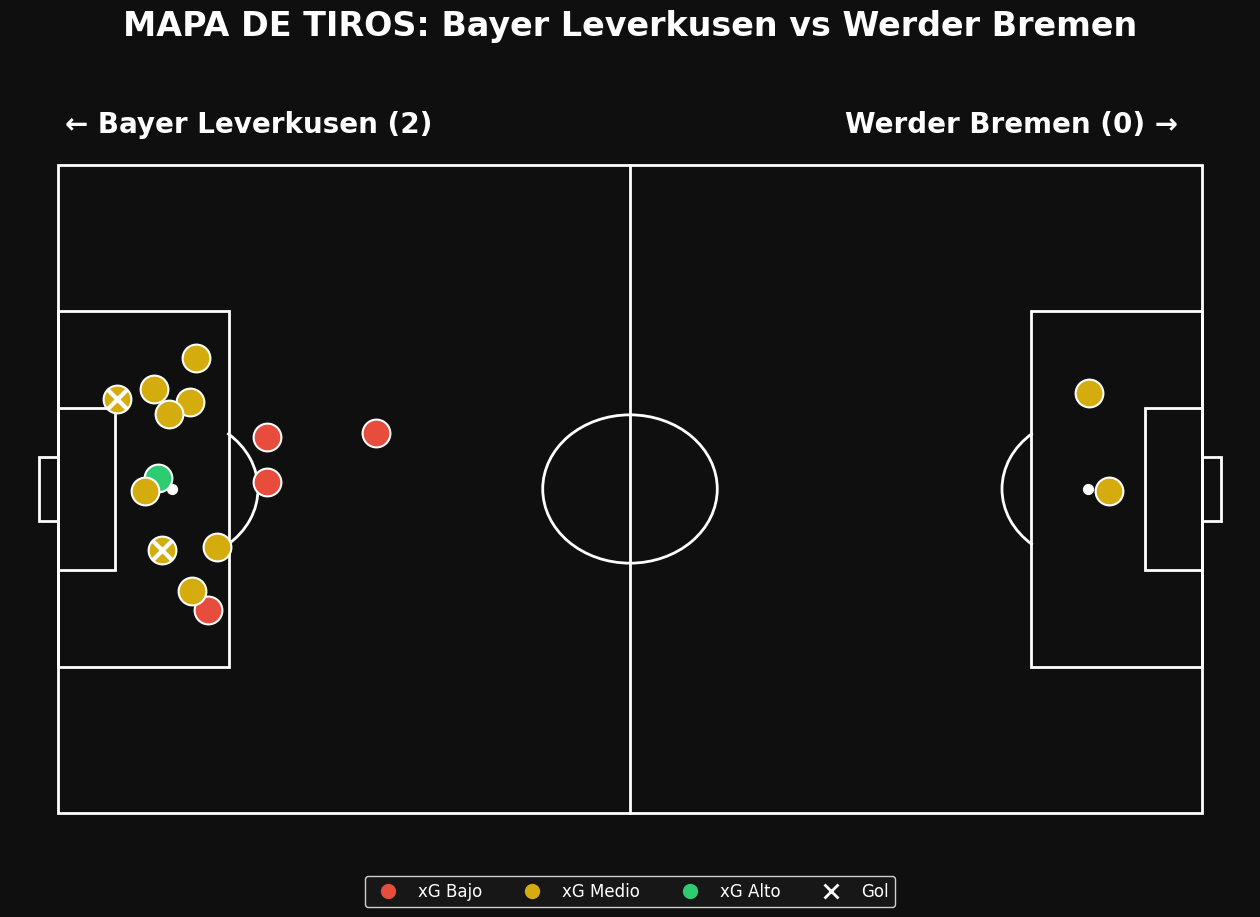

In [5]:
def dibujar_cancha(ax):
    # Rectángulo del campo
    campo = mpatches.Rectangle([0, 0], 120, 80, linewidth=2, edgecolor="white", facecolor="#0f0f0f", zorder=0)
    ax.add_patch(campo)

    # Líneas medias y circulares
    ax.plot([60, 60], [0, 80], color="white", linewidth=2, zorder=0)  # Línea central
    centro_campo = mpatches.Circle((60, 40), 9.15, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    ax.add_patch(centro_campo)

    # Áreas grandes
    area_grande_izq = mpatches.Rectangle([0, 18], 18, 44, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    area_grande_der = mpatches.Rectangle([102, 18], 18, 44, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    ax.add_patch(area_grande_izq)
    ax.add_patch(area_grande_der)

    # Áreas chicas
    area_chica_izq = mpatches.Rectangle([0, 30], 6, 20, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    area_chica_der = mpatches.Rectangle([114, 30], 6, 20, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    ax.add_patch(area_chica_izq)
    ax.add_patch(area_chica_der)

    # Arcos
    arco_izq = mpatches.Rectangle([-2, 36], 2, 8, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    arco_der = mpatches.Rectangle([120, 36], 2, 8, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    ax.add_patch(arco_izq)
    ax.add_patch(arco_der)

    # Puntos de penal
    ax.scatter(12, 40, color="white", s=50, zorder=0)
    ax.scatter(108, 40, color="white", s=50, zorder=0)

    # Medias lunas
    arco_penal_izq = mpatches.Arc((12, 40), height=18, width=18, angle=0, theta1=310, theta2=50, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    arco_penal_der = mpatches.Arc((108, 40), height=18, width=18, angle=0, theta1=130, theta2=230, linewidth=2, edgecolor="white", facecolor="none", zorder=0)
    ax.add_patch(arco_penal_izq)
    ax.add_patch(arco_penal_der)

def normalizar_tiros_por_lados(df, equipo_local):
    """
    Fuerza que el equipo local ataque hacia la IZQUIERDA (x=0)
    y el visitante ataque hacia la DERECHA (x=120).
    """
    df = df.copy()
    def ajustar(row):
        x, y = row["x"], row["y"]
        # StatsBomb tiene a todos hacia x=120.
        # Si es el local, lo mandamos al otro arco (x=0)
        if row["team"] == equipo_local:
            x = 120 - x
            y = 80 - y
        # El visitante se queda como está (ya ataca hacia la derecha)
        return pd.Series({"x_norm": x, "y_norm": y})

    df[["x_norm", "y_norm"]] = df.apply(ajustar, axis=1)
    return df

def plot_mapa_final_espejo(match_id):
    # 1. Preparación de datos
    df_partido = tiros[tiros["match_id"] == match_id].copy()
    equipos = df_partido["team"].unique()
    e_local, e_visit = equipos[0], equipos[1]

    # Marcador real desde los datos
    goles_local = df_partido[df_partido["team"] == e_local]["gol"].sum()
    goles_visit = df_partido[df_partido["team"] == e_visit]["gol"].sum()

    # APLICAR NUEVA NORMALIZACIÓN POR LADOS
    df_partido = normalizar_tiros_por_lados(df_partido, e_local)

    fig, ax = plt.subplots(figsize=(16, 10))
    fig.patch.set_facecolor("#0f0f0f")
    ax.set_facecolor("#0f0f0f")
    dibujar_cancha(ax)

    # Colores: Rojo (Bajo), Oro (Medio), Verde (Alto)
    def obtener_color(xg):
        if xg < 0.07: return "#e74c3c"
        if xg < 0.25: return "#d4ac0d"
        return "#2ecc71"

    # Tamaño uniforme para ver bien las cruces de gol
    TAMANO_PUNTO = 400

    for _, t in df_partido.iterrows():
        color_tiro = obtener_color(t["prob_gol"])

        ax.scatter(t["x_norm"], t["y_norm"],
                   s=TAMANO_PUNTO, color=color_tiro,
                   edgecolors="white", linewidths=1.5, zorder=5)

        if t["gol"] == 1:
            ax.scatter(t["x_norm"], t["y_norm"], marker="x",
                       color="white", s=TAMANO_PUNTO/2,
                       linewidths=3, zorder=6)

    # --- LEYENDA ---
    l1 = Line2D([], [], color='#e74c3c', marker='o', linestyle='None', markersize=10, label='xG Bajo')
    l2 = Line2D([], [], color='#d4ac0d', marker='o', linestyle='None', markersize=10, label='xG Medio')
    l3 = Line2D([], [], color='#2ecc71', marker='o', linestyle='None', markersize=10, label='xG Alto')
    l4 = Line2D([], [], color='white', marker='x', linestyle='None', markersize=10, markeredgewidth=2, label='Gol')

    leg = ax.legend(handles=[l1, l2, l3, l4], loc="lower center", bbox_to_anchor=(0.5, -0.08),
                    ncol=4, fontsize=12, facecolor="#1a1a1a", edgecolor="white")
    plt.setp(leg.get_texts(), color='w')

    # --- TÍTULOS (Marcador automático) ---
    # Lado izquierdo: equipo local | Lado derecho: equipo visitante
    ax.text(20, 84, f"← {e_local} ({int(goles_local)})", color="white",
            fontsize=20, fontweight="bold", ha="center")
    ax.text(100, 84, f"{e_visit} ({int(goles_visit)}) →", color="white",
            fontsize=20, fontweight="bold", ha="center")

    plt.title(f"MAPA DE TIROS: {e_local} vs {e_visit}",
              color="white", fontsize=24, pad=35, fontweight="bold")

    ax.set_xlim(-5, 125); ax.set_ylim(-5, 90); ax.axis("off")
    plt.show()

# Ejecutar
plot_mapa_final_espejo(MATCH_ID)

# 6. Análisis de resultados
Top 5 de tiros más peligrosos del partido según el modelo entrenado.


In [6]:
columnas_finales = ["player", "minute", "distancia", "angulo", "prob_gol", "gol"]

# Define tiros_partido and equipos globally based on MATCH_ID
tiros_partido = tiros[tiros["match_id"] == MATCH_ID].copy()
equipos = tiros_partido["team"].unique()

print(f"Tiros más peligrosos - {equipos[0]} vs {equipos[1]}:")
print(tiros_partido[tiros_partido["es_penal"] == 0][columnas_finales]
      .sort_values("prob_gol", ascending=False).head(5).to_string(index=False))

Tiros más peligrosos - Bayer Leverkusen vs Werder Bremen:
                   player  minute  distancia    angulo  prob_gol  gol
     Victor Okoh Boniface      16  10.580170  7.057847  0.385362    0
         Jeremie Frimpong      42  13.231024 34.530826  0.228427    1
             Nadiem Amiri      91  14.883884 38.178848  0.214142    0
Alejandro Grimaldo García      75  12.714165 60.814084  0.188711    1
     Victor Okoh Boniface      68  15.915401 50.609274  0.173075    0
